<a href="https://colab.research.google.com/github/ThandoZwane06/Cisco-Data-Science-Essentials/blob/main/Lessons%20/%20Week_4_Lessons%20/%20AirBnB_Listing_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
Listings_df = pd.read_csv('/content/drive/MyDrive/Colab Datasets/Listings.csv', encoding='latin1')
Listings_df.head()


/tmp/ipykernel_1361/3317119188.py:1: DtypeWarning: Columns (5,13) have mixed types. Specify dtype option on import or set low_memory=False.
  Listings_df = pd.read_csv('/content/drive/MyDrive/Colab Datasets/Listings.csv', encoding='latin1')


,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [ ]:
Listings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                278872 non-null  object 
 5   host_response_time           150930 non-null  object 
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  object 
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  object 
 11  host_identity_verified       279547 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

In [ ]:
Listings_df.isna().sum()

,0
listing_id,0
name,175
host_id,0
host_since,165
host_location,840
host_response_time,128782
host_response_rate,128782
host_acceptance_rate,113087
host_is_superhost,165
host_total_listings_count,165


In [ ]:
reviews_df = pd.read_csv('/content/drive/MyDrive/Colab Datasets/Reviews.csv')
reviews_df.head()

,listing_id,review_id,date,reviewer_id
0,11798,330265172,2018-09-30,11863072
1,15383,330103585,2018-09-30,39147453
2,16455,329985788,2018-09-30,1125378
3,17919,330016899,2018-09-30,172717984
4,26827,329995638,2018-09-30,17542859


In [ ]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5373143 entries, 0 to 5373142
Data columns (total 4 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   listing_id   int64 
 1   review_id    int64 
 2   date         object
 3   reviewer_id  int64 
dtypes: int64(3), object(1)
memory usage: 164.0+ MB


In [ ]:
reviews_df.isna().sum()


,0
listing_id,0
review_id,0
date,0
reviewer_id,0


In [ ]:
#cast any date columns as a datetime format
#Listings
Listings_df['host_since'] = pd.to_datetime(Listings_df['host_since'])

#reviews
reviews_df['date'] = pd.to_datetime(reviews_df['date'])

In [ ]:
cities = Listings_df['city'].value_counts()
cities

,count
city,
Paris,64690
New York,37012
Sydney,33630
Rome,27647
Rio de Janeiro,26615
Istanbul,24519
Mexico City,20065
Bangkok,19361
Cape Town,19086


In [ ]:
#grab the required columns
listings = Listings_df[ ["host_since", "neighbourhood", "city", "accommodates", "price"] ]

listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   host_since     279547 non-null  datetime64[ns]
 1   neighbourhood  279712 non-null  object        
 2   city           279712 non-null  object        
 3   accommodates   279712 non-null  int64         
 4   price          279712 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 10.7+ MB


In [ ]:

#look at one city
paris_listing = listings.query("city == 'Paris'")

paris_listing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64690 entries, 0 to 279711
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   host_since     64657 non-null  datetime64[ns]
 1   neighbourhood  64690 non-null  object        
 2   city           64690 non-null  object        
 3   accommodates   64690 non-null  int64         
 4   price          64690 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 3.0+ MB


In [ ]:
paris_listing.isna().sum()

,0
host_since,33
neighbourhood,0
city,0
accommodates,0
price,0


In [ ]:
paris_listing.describe()


,host_since,accommodates,price
count,64657,64690.000000,64690.000000
mean,2015-11-01 11:06:05.528867584,3.037997,113.096445
min,2008-08-30 00:00:00,0.000000,0.000000
25%,2014-03-09 00:00:00,2.000000,59.000000
50%,2015-07-07 00:00:00,2.000000,80.000000
75%,2017-05-29 00:00:00,4.000000,120.000000
max,2021-02-07 00:00:00,16.000000,12000.000000
std,NaN,1.588766,214.433668


In [ ]:
#check the rows where minimum accomodates is zero
paris_listing.query("accommodates == 0")

,host_since,neighbourhood,city,accommodates,price
98209,2020-07-20,Pantheon,Paris,0,0
203257,2020-02-04,Batignolles-Monceau,Paris,0,0
203258,2016-10-17,Opera,Paris,0,0
203259,2020-04-24,Luxembourg,Paris,0,0
203260,2020-04-24,Vaugirard,Paris,0,0
203261,2020-07-15,Batignolles-Monceau,Paris,0,0
203263,2016-06-07,Palais-Bourbon,Paris,0,0
203264,2020-09-08,Pantheon,Paris,0,0
203265,2020-09-21,Vaugirard,Paris,0,0
203267,2020-10-29,Observatoire,Paris,0,0


In [ ]:
#check rows where the price is zero
paris_listing.query("price == 0").head()

,host_since,neighbourhood,city,accommodates,price
98209,2020-07-20,Pantheon,Paris,0,0
203257,2020-02-04,Batignolles-Monceau,Paris,0,0
203258,2016-10-17,Opera,Paris,0,0
203259,2020-04-24,Luxembourg,Paris,0,0
203260,2020-04-24,Vaugirard,Paris,0,0


In [ ]:
#look at rows where date is NaN
paris_listing.query("host_since.isna()").head()

,host_since,neighbourhood,city,accommodates,price
52879,NaT,Enclos-St-Laurent,Paris,2,57
52880,NaT,Enclos-St-Laurent,Paris,2,58
52881,NaT,Batignolles-Monceau,Paris,4,90
52882,NaT,Buttes-Montmartre,Paris,5,89
52883,NaT,Hotel-de-Ville,Paris,2,119


In [ ]:
#group by neighbourhood and calculate mean
paris_list_neigh = paris_listing.groupby('neighbourhood')['price'].mean().round(2)
paris_list_neigh = paris_list_neigh.sort_values().reset_index()
paris_list_neigh.tail()

,neighbourhood,price
15,Luxembourg,155.64
16,Palais-Bourbon,156.86
17,Passy,161.14
18,Louvre,175.38
19,Elysee,210.54


In [84]:
#filter to most expensive
paris_list_accom = paris_listing.query("neighbourhood == 'Elysee'").groupby('accommodates')['price'].mean().round(2).sort_values().reset_index()
paris_list_accom.tail()

,accommodates,price
11,12,529.62
12,16,800.00
13,11,805.00
14,13,842.50
15,14,971.00


In [61]:
#listings over time
#extract the year
paris_listing['year_joined'] = paris_listing['host_since'].dt.year.astype('Int64')
#listings each year
neigh_listings = paris_listing.groupby('year_joined')['neighbourhood'].count()
#average price each year
avg_price = paris_listing.groupby('year_joined')['price'].mean().round(2)
#df
paris_list_overtime = pd.DataFrame({'new_hosts': neigh_listings, "avg_price": avg_price})
paris_list_overtime

/tmp/ipykernel_1361/1367945919.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  paris_listing['year_joined'] = paris_listing['host_since'].dt.year.astype('Int64')


,new_hosts,avg_price
year_joined,,
2008,4,77.75
2009,106,159.64
2010,416,125.03
2011,1339,124.83
2012,4592,111.58
2013,8142,107.10
2014,10922,100.25
2015,12147,103.65
2016,8871,114.16


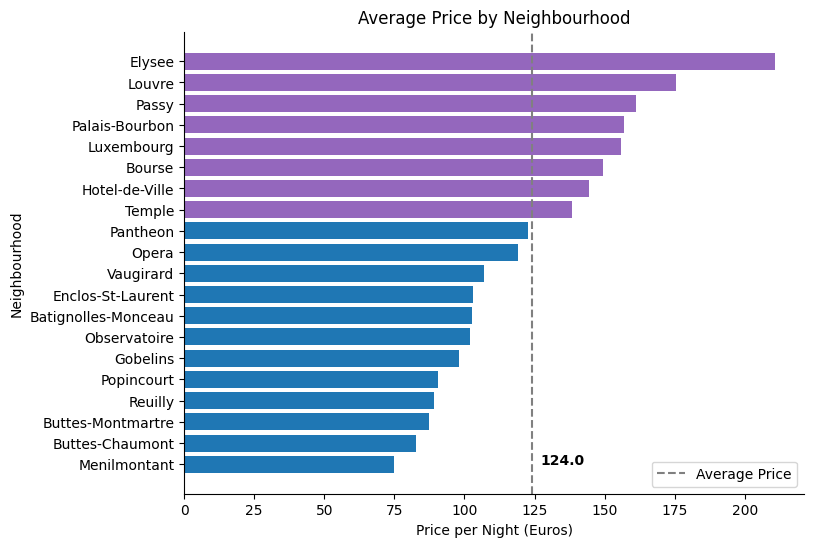

In [81]:
#mean line
mean_price = paris_list_neigh['price'].mean().round()

#set the bar colors depending on the condition
bar_colors = ['C0' if price < mean_price else 'C4' for price in paris_list_neigh['price']]

plt.figure(figsize=(8,6))
plt.barh(paris_list_neigh['neighbourhood'], paris_list_neigh['price'], color=bar_colors)


#add the vertical line
plt.axvline(x=mean_price, color='grey', linestyle='--', label='Average Price')


#add the text
plt.text(x=mean_price+3,y=0,s=f'{mean_price}',color='black',fontweight='bold')

#remove the spines
plt.gca().spines[['top','right']].set_visible(False)

#add labels

plt.xlabel('Price per Night (Euros)')
plt.ylabel('Neighbourhood')
plt.title('Average Price by Neighbourhood')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Average Price by Accommodation Capacity')

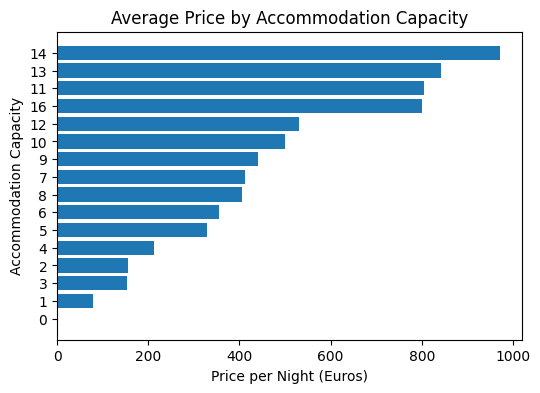

In [82]:
#average price by accommodation capacity
#convert accomodates column to a string
paris_list_accom['accommodates'] = paris_list_accom['accommodates'].astype(str)

#figure chart
plt.figure(figsize=(6,4))
plt.barh(paris_list_accom['accommodates'], paris_list_accom['price'])


plt.xlabel('Price per Night (Euros)')
plt.ylabel('Accommodation Capacity')
plt.title('Average Price by Accommodation Capacity')

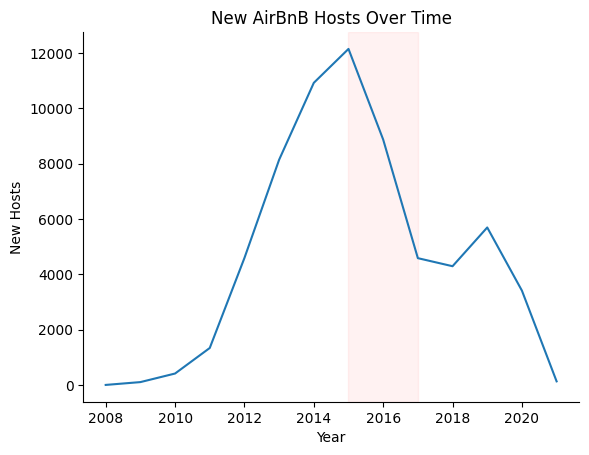

In [74]:
plt.plot(paris_list_overtime.index, paris_list_overtime['new_hosts'])

#highlight the sharp decrease
plt.axvspan(2015, 2017, color='red', alpha=0.05)

plt.xlabel('Year')
plt.ylabel('New Hosts')
plt.title('New AirBnB Hosts Over Time')
plt.gca().spines[['top', 'right']].set_visible(False)


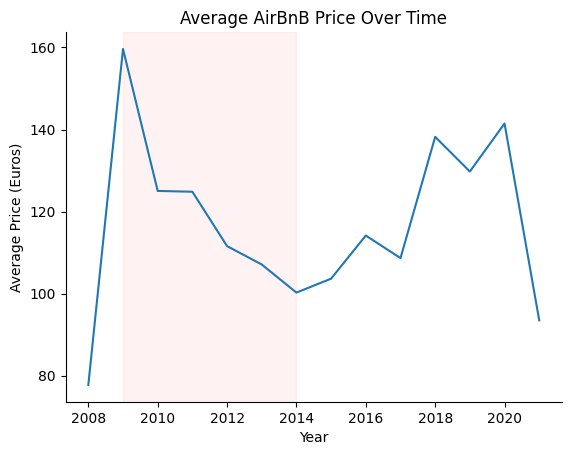

In [79]:
plt.plot(paris_list_overtime.index, paris_list_overtime['avg_price'])

plt.axvspan(2009, 2014, color='red', alpha=0.05)

plt.xlabel('Year')
plt.ylabel('Average Price (Euros)')
plt.title('Average AirBnB Price Over Time')
plt.gca().spines[['top', 'right']].set_visible(False)
